# Linkage Methods for Hierarchical Clustering
<img src="image/linkage_distance_0.png" width="600">


## 1. Single Linkage(Nearest Neighbour)
### Minimum distance between any pair of points
<img src="image/linkage_distance_1.png" width="600">


## 2. Complete Linkage (Farthest Neighbor)
### Maximum distance between any pair of points
<img src="image/linkage_distance_2.png" width="600">

## 3. Average Linkage
### Average pairwise distance between points
<img src="image/linkage_distance_3.png" width="600">

## 4. Centroid Linkage
### Distance between cluster centroids
<img src="image/linkage_distance_4.png" width="600">

## 5. Ward’s Method (Minimum Variance)
### Increase in within-cluster variance (SSE) after merging
<img src="image/linkage_distance_5.png" width="600">

In [11]:
# Cell 1: Imports
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering

# For dendrogram (needs scipy)
from scipy.cluster.hierarchy import dendrogram, linkage

In [20]:
# Cell 2: Create sample data (you can replace this with your own X)
number_of_clusters = 4
X, y_true = make_blobs(
    n_samples=100,
    centers=number_of_clusters,
    cluster_std=8,
    random_state=42
)

# Optional scaling (recommended for distance-based clustering)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("X shape:", X_scaled.shape)

X shape: (100, 2)


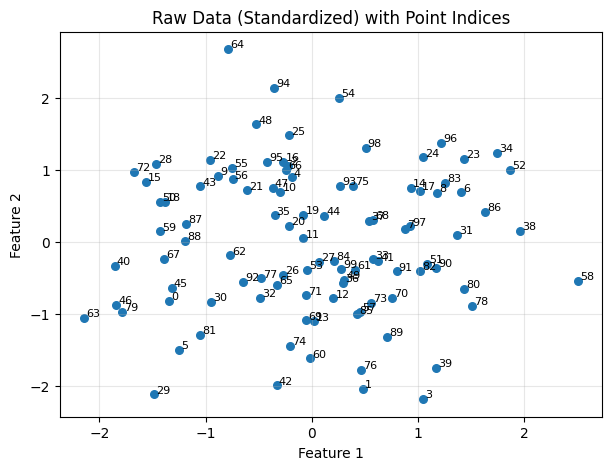

In [21]:
# Cell 3 (modified): Plot raw data with point numbers
plt.figure(figsize=(7, 5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], s=30)

for i in range(len(X_scaled)):
    plt.text(
        X_scaled[i, 0] + 0.02,  # small offset in x
        X_scaled[i, 1] + 0.02,  # small offset in y
        str(i),
        fontsize=8
    )

plt.title("Raw Data (Standardized) with Point Indices")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True, alpha=0.3)
plt.show()

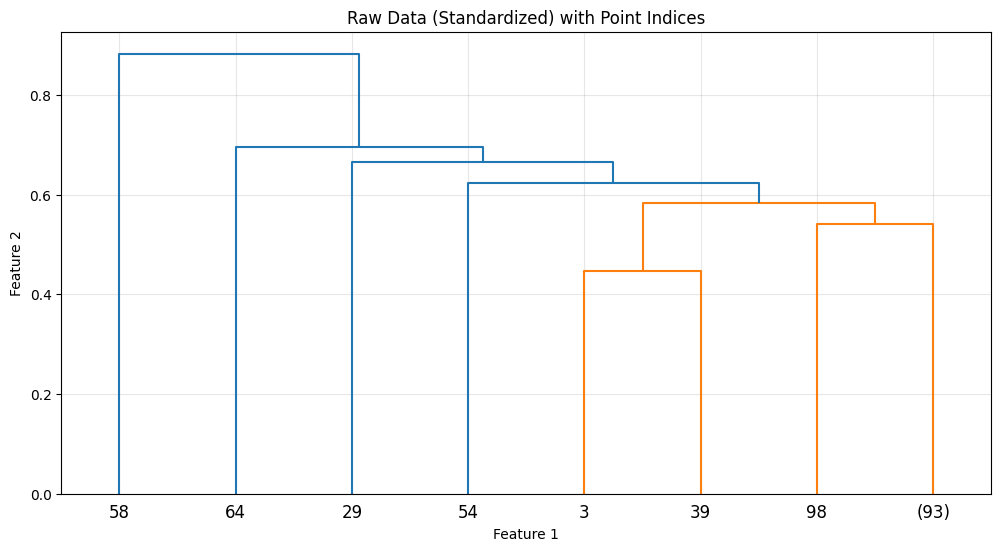

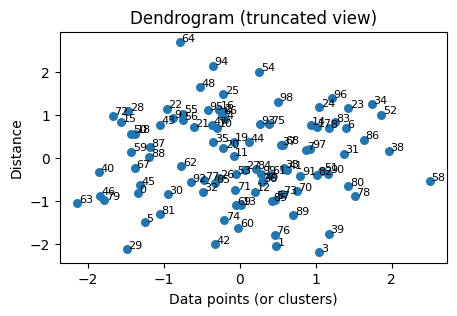

In [22]:
# Cell 4: Dendrogram (visualize how clusters merge)
# linkage() creates the hierarchical merge tree
# method options: 'ward', 'complete', 'average', 'single'
Z = linkage(X_scaled, method='single')  # 'ward' works best with Euclidean distance

plt.figure(figsize=(12, 6)) # width, height
dendrogram(Z, truncate_mode='level', p=5)  # show only top levels for readability

cut_height = -1
plt.axhline(y=cut_height, color='r', linestyle='--', linewidth=2)

plt.title("Raw Data (Standardized) with Point Indices")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(5, 3))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], s=30)

for i in range(len(X_scaled)):
    plt.text(
        X_scaled[i, 0] + 0.02,  # small offset in x
        X_scaled[i, 1] + 0.02,  # small offset in y
        str(i),
        fontsize=8
    )
    
plt.title("Dendrogram (truncated view)")
plt.xlabel("Data points (or clusters)")
plt.ylabel("Distance")
plt.show()

In [23]:
# Cell 5: Agglomerative Clustering (choose number of clusters)
k = number_of_clusters

model = AgglomerativeClustering(
    n_clusters=k,
    linkage='ward'  # ward requires metric='euclidean'
)

labels = model.fit_predict(X_scaled)

print("Unique labels:", np.unique(labels))

Unique labels: [0 1 2 3]


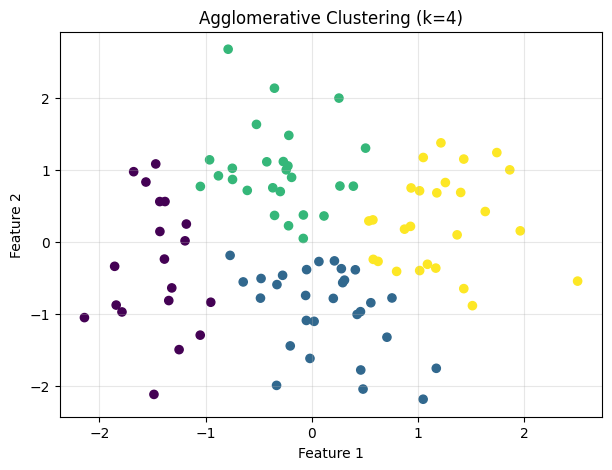

In [24]:
# Cell 6: Plot clustered output
plt.figure(figsize=(7, 5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, s=35)
plt.title(f"Agglomerative Clustering (k={k})")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True, alpha=0.3)
plt.show()

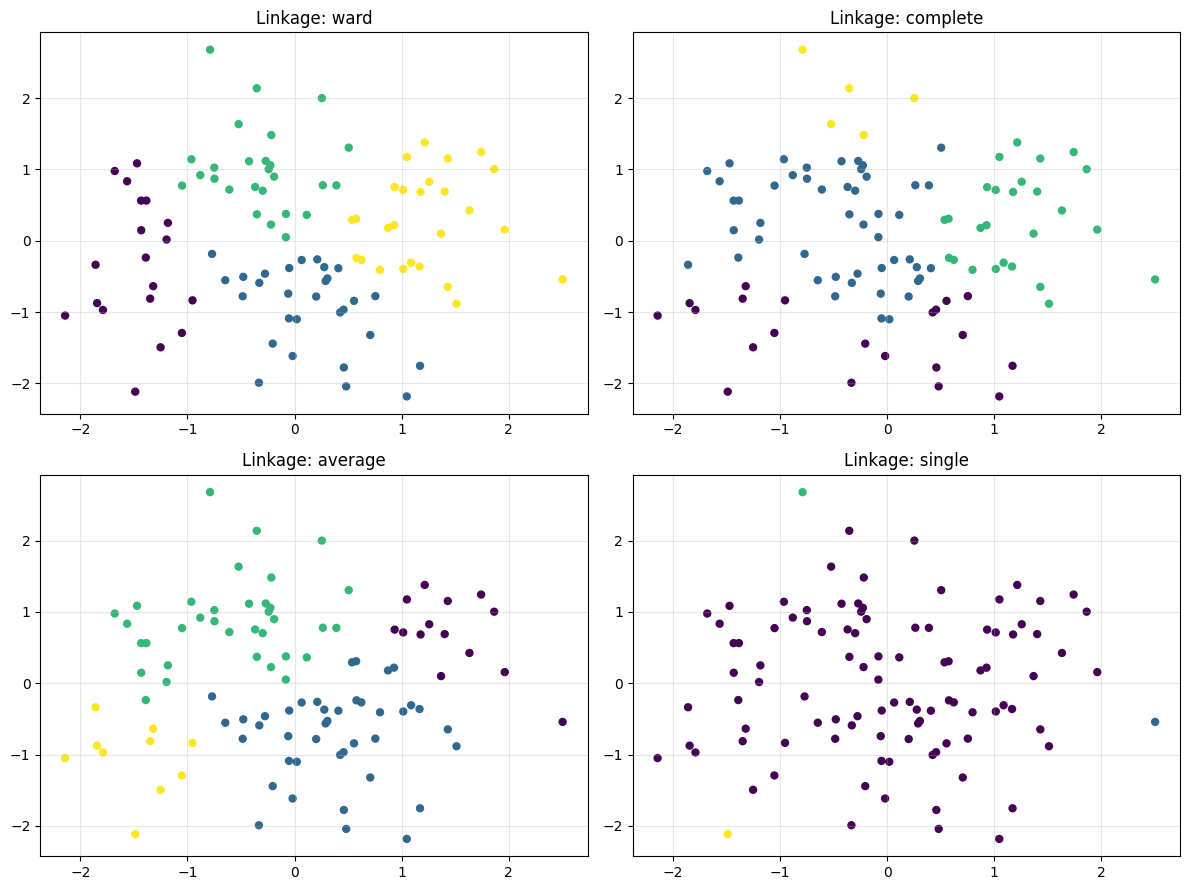

In [25]:
# Cell 7 (Optional): Try different linkage methods (quick comparison)
linkages = ['ward', 'complete', 'average', 'single']

plt.figure(figsize=(12, 9))
for i, lk in enumerate(linkages, 1):
    if lk == 'ward':
        m = AgglomerativeClustering(n_clusters=4, linkage=lk)
    else:
        # complete/average/single: metric can be 'euclidean', 'manhattan', 'cosine', etc.
        m = AgglomerativeClustering(n_clusters=4, linkage=lk, metric='euclidean')
    
    lab = m.fit_predict(X_scaled)
    
    plt.subplot(2, 2, i)
    plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=lab, s=25)
    plt.title(f"Linkage: {lk}")
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculation of Single Linkage Distance Matrix

## Data Points

### A(1,1), B(2,3), C(3,6), D(4,5) and E(7,7)


### Compute Pairwise Distance
<img src="image/linkage_pairwise_distance.png" width="800">

## First Iteration
<img src="image/single_linkage_matrix_1.png" width="800">

## Second Iteration
<img src="image/single_linkage_matrix_2.png" width="800">

## Third Iteration
<img src="image/single_linkage_matrix_3.png" width="600">

## Fourth Iteration
<img src="image/single_linkage_matrix_4.png" width="600">

## Dendogram

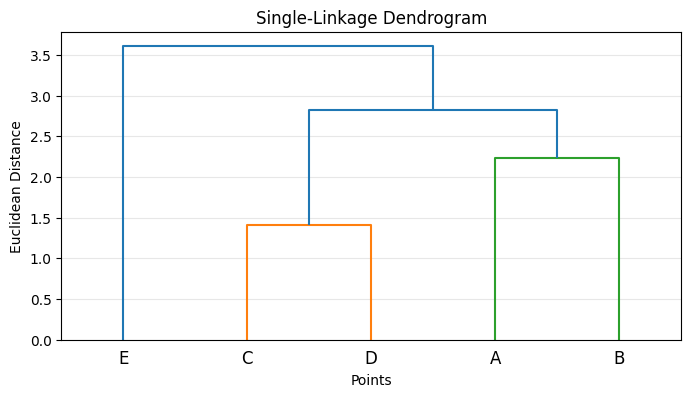

In [8]:
# Points in order: A, B, C, D, E, F
X = np.array([
    [1, 1],  # A
    [2, 3],  # B
    [3, 6],  # C
    [4, 5],  # D
    [7, 7]  # E
])

labels = ['A', 'B', 'C', 'D', 'E']

# Single linkage
Z = linkage(X, method='single', metric='euclidean')

plt.figure(figsize=(8, 4))
dendrogram(
    Z,
    labels=labels,
    distance_sort='ascending'
)

plt.title("Single-Linkage Dendrogram")
plt.xlabel("Points")
plt.ylabel("Euclidean Distance")
plt.grid(True, axis='y', alpha=0.3)
plt.show()

Point A → Cluster 2
Point B → Cluster 2
Point C → Cluster 1
Point D → Cluster 1
Point E → Cluster 3


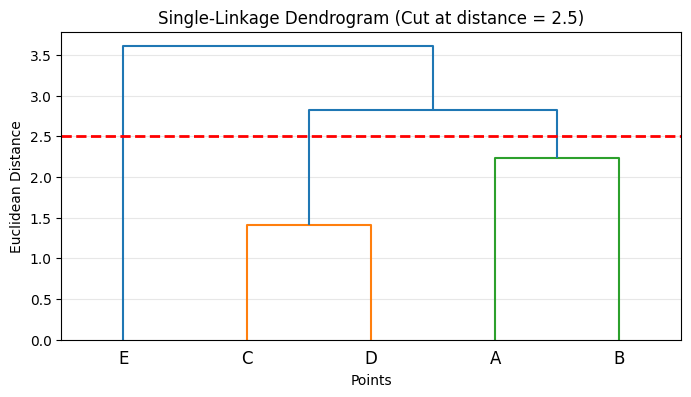

In [28]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# Data
X = np.array([
    [1, 1],  # A
    [2, 3],  # B
    [3, 6],  # C
    [4, 5],  # D
    [7, 7]   # E
])

labels = ['A', 'B', 'C', 'D', 'E']

# Single linkage
Z = linkage(X, method='single', metric='euclidean')

# ---- CUT HEIGHT ----
cut_height = 2.5

clusters = fcluster(Z, t=cut_height, criterion='distance')

for point, cluster in zip(labels, clusters):
    print(f"Point {point} → Cluster {cluster}")

plt.figure(figsize=(8, 4))
dendrogram(Z, labels=labels, distance_sort='ascending')
plt.axhline(y=cut_height, color='r', linestyle='--', linewidth=2)

plt.title(f"Single-Linkage Dendrogram (Cut at distance = {cut_height})")
plt.xlabel("Points")
plt.ylabel("Euclidean Distance")
plt.grid(True, axis='y', alpha=0.3)
plt.show()